In [102]:
import torch
from keras.datasets import mnist
import matplotlib.pyplot as plt
import cv2
import torch.nn as nn 
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchinfo import summary

In [103]:
""""
self.conv1 = nn.Conv2d(
    in_channels=1,    # input channel (e.g. grayscale image)
    out_channels=6,   # কতগুলো ফিচার ম্যাপ বের হবে
    kernel_size=5,    # প্রতিটা ফিল্টারের আকার 5x5
    stride=1,         # এক ধাপ করে ফিল্টার সরে যাবে
    padding=2         # চারপাশে 2 পিক্সেল জিরো প্যাড যোগ হবে
)
"""

'"\nself.conv1 = nn.Conv2d(\n    in_channels=1,    # input channel (e.g. grayscale image)\n    out_channels=6,   # কতগুলো ফিচার ম্যাপ বের হবে\n    kernel_size=5,    # প্রতিটা ফিল্টারের আকার 5x5\n    stride=1,         # এক ধাপ করে ফিল্টার সরে যাবে\n    padding=2         # চারপাশে 2 পিক্সেল জিরো প্যাড যোগ হবে\n)\n'

In [104]:
class LeNet5_MNIST_Sequential(nn.Module):
    def __init__(self):
        super(LeNet5_MNIST_Sequential, self).__init__()

        # Convolution + ReLU + Pool Layers
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2), # 28*28
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2), # 14x14

            nn.Conv2d(6, 16, kernel_size=5, stride=1),  # 10x10
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2) # 5*5
        )

        # Fully Connected Layers
        self.classifier = nn.Sequential(
            nn.Linear(16*5*5, 120), # 16*5*5 = 400
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )


    def forward(self, x):
        x = self.features(x) 
        """ 
        x.size(0) = 1 → batch size ঠিক থাকে
        -1 → 400 features auto calculate হবে
        x = [1,400]
        """
        x = x.view(x.size(0), -1)  # flatten
        x = self.classifier(x)
        return x

In [ ]:
import torch
from keras.datasets import mnist
import matplotlib.pyplot as plt
import cv2
import torch.nn as nn 
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchinfo import summary

class LeNet5_MNIST_Sequential(nn.Module):
    def __init__(self):
        super(LeNet5_MNIST_Sequential, self).__init__()

        # Convolution + ReLU + Pool Layers
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2), # 28*28
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2), # 14x14

            nn.Conv2d(6, 16, kernel_size=5, stride=1),  # 10x10
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2) # 5*5
        )

        # Fully Connected Layers
        self.classifier = nn.Sequential(
            nn.Linear(16*5*5, 120), # 16*5*5 = 400
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )


    def forward(self, x):
        x = self.features(x) 
        """ 
        x.size(0) = 1 → batch size ঠিক থাকে
        -1 → 400 features auto calculate হবে
        x = [1,400]
        """
        x = x.view(x.size(0), -1)  # flatten
        x = self.classifier(x)
        return x
    
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST dataset এর mean=0.1307, std=0.3081
])


batch_size = 64
epochs = 20
learning_rate = 0.001
train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
# model, loss and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LeNet5_MNIST_Sequential().to(device)
criterion = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=learning_rate)


# Training
train_losses = []
test_accuracy = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.00
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        # pass image batch
        prediction = model(images)
        loss = criterion(prediction, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/ {epochs}, Loss: {avg_loss:.4f}")


    # Evaluation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total 
    test_accuracy.append(accuracy)
    print(f"Test accuracy is : {accuracy:.2f}%")

# save model
torch.save(model.state_dict(), "lenet5_mnist.pth")

loaded_model = LeNet5_MNIST_Sequential().to(device)
loaded_model.load_state_dict(torch.load("lenet5_mnist.pth", map_location=device))

def predict_image(image):
    loaded_model.eval()
    with torch.no_grad():
        image = image.to(device).unsqueeze(0) # Add batch dimension 
        output = loaded_model(image)
        _, predicted = torch.max(output, 1)

    return predicted.item()

In [105]:
model_se = LeNet5_MNIST_Sequential()
summary(model_se, (1, 1, 28, 28))


Layer (type:depth-idx)                   Output Shape              Param #
LeNet5_MNIST_Sequential                  [1, 10]                   --
├─Sequential: 1-1                        [1, 16, 5, 5]             --
│    └─Conv2d: 2-1                       [1, 6, 28, 28]            156
│    └─ReLU: 2-2                         [1, 6, 28, 28]            --
│    └─AvgPool2d: 2-3                    [1, 6, 14, 14]            --
│    └─Conv2d: 2-4                       [1, 16, 10, 10]           2,416
│    └─ReLU: 2-5                         [1, 16, 10, 10]           --
│    └─AvgPool2d: 2-6                    [1, 16, 5, 5]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Linear: 2-7                       [1, 120]                  48,120
│    └─ReLU: 2-8                         [1, 120]                  --
│    └─Linear: 2-9                       [1, 84]                   10,164
│    └─ReLU: 2-10                        [1, 84]                   --
│  

In [106]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST dataset এর mean=0.1307, std=0.3081
])

In [107]:
transform

Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)

In [108]:
batch_size = 64
epochs = 20
learning_rate = 0.001

In [ ]:

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:13<00:00, 754kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 93.9kB/s]
100%|██████████| 1.65M/1.65M [00:05<00:00, 311kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.31MB/s]


In [110]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# model, loss and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [112]:
model = LeNet5_MNIST_Sequential().to(device)
model

LeNet5_MNIST_Sequential(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
    (4): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=learning_rate)

In [114]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [133]:
# Training
train_losses = []
test_accuracy = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.00
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        # pass image batch
        prediction = model(images)
        loss = criterion(prediction, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/ {epochs}, Loss: {avg_loss:.4f}")


    # Evaluation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total 
    test_accuracy.append(accuracy)
    print(f"Test accuracy is : {accuracy:.2f}%")



Epoch 1/ 20, Loss: 0.0067
Test accuracy is : 98.94%
Epoch 2/ 20, Loss: 0.0067
Test accuracy is : 98.97%
Epoch 3/ 20, Loss: 0.0068
Test accuracy is : 98.69%
Epoch 4/ 20, Loss: 0.0058
Test accuracy is : 99.09%
Epoch 5/ 20, Loss: 0.0065
Test accuracy is : 99.19%
Epoch 6/ 20, Loss: 0.0066
Test accuracy is : 99.11%
Epoch 7/ 20, Loss: 0.0066
Test accuracy is : 99.13%
Epoch 8/ 20, Loss: 0.0043
Test accuracy is : 99.06%
Epoch 9/ 20, Loss: 0.0057
Test accuracy is : 99.09%
Epoch 10/ 20, Loss: 0.0047
Test accuracy is : 99.01%
Epoch 11/ 20, Loss: 0.0051
Test accuracy is : 99.19%
Epoch 12/ 20, Loss: 0.0040
Test accuracy is : 99.21%
Epoch 13/ 20, Loss: 0.0045
Test accuracy is : 99.12%
Epoch 14/ 20, Loss: 0.0024
Test accuracy is : 99.13%
Epoch 15/ 20, Loss: 0.0075
Test accuracy is : 99.02%
Epoch 16/ 20, Loss: 0.0024
Test accuracy is : 98.91%
Epoch 17/ 20, Loss: 0.0036
Test accuracy is : 99.01%
Epoch 18/ 20, Loss: 0.0063
Test accuracy is : 99.02%
Epoch 19/ 20, Loss: 0.0049
Test accuracy is : 99.03%
Ep

In [ ]:
torch.save(model.state_dict(), "lenet5_mnist.pth")

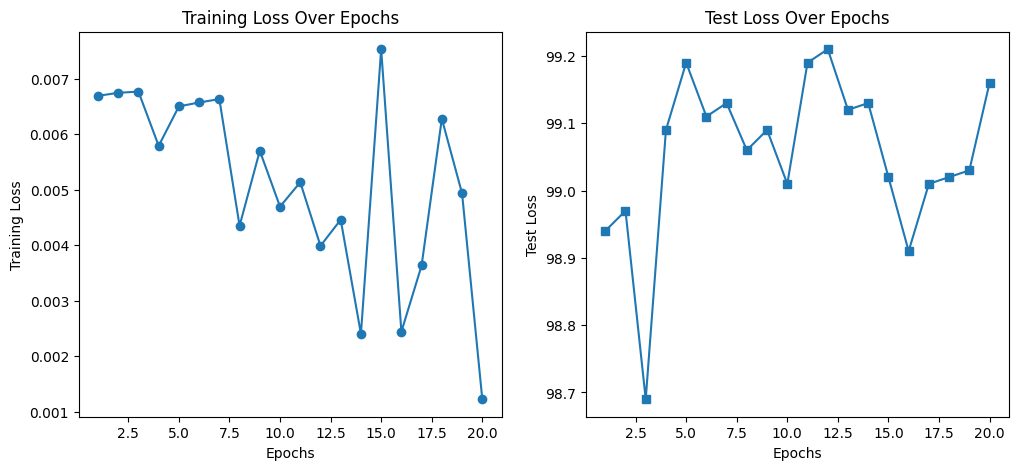

In [135]:
# plot accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, marker="o", linestyle="-")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), test_accuracy, marker="s", linestyle="-")
plt.xlabel("Epochs")
plt.ylabel("Test Loss")
plt.title("Test Loss Over Epochs")
plt.show()

In [148]:
# Interface function
def predict_image(image):
    model.eval()
    with torch.no_grad():
        image = image.to(device).unsqueeze(0) # Add batch dimension
        print(image)
        output = model(image)
        _, predicted = torch.max(output, 1)

    return predicted.item()

tensor([[[[-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.424

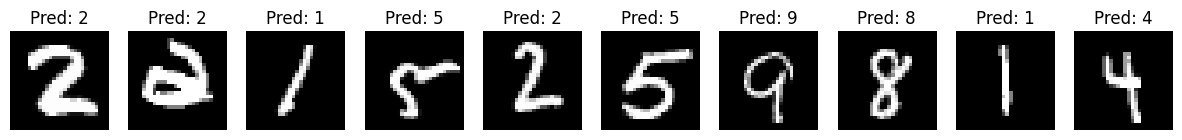

In [149]:
samples, labels = next(iter(test_loader))
samples, labels = samples.to(device), labels.to(device)
predictions = [predict_image(img) for img in samples[:10]]

fig, axes = plt.subplots(1, 10, figsize=(15, 6))
for i, ax in enumerate(axes):
    ax.imshow(samples[i].cpu().squeeze(), cmap="gray")
    ax.set_title(f"Pred: {predictions[i]}")
    ax.axis("off")
plt.show()

In [144]:
loaded_model = LeNet5_MNIST_Sequential().to(device)
loaded_model.load_state_dict(torch.load("lenet5_mnist.pth", map_location=device))

def predict_image(image):
    loaded_model.eval()
    with torch.no_grad():
        image = image.to(device).unsqueeze(0) # Add batch dimension
        print(image)
        print(type(image))
        output = loaded_model(image)
        _, predicted = torch.max(output, 1)

    return predicted.item()

tensor([[[[-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.424

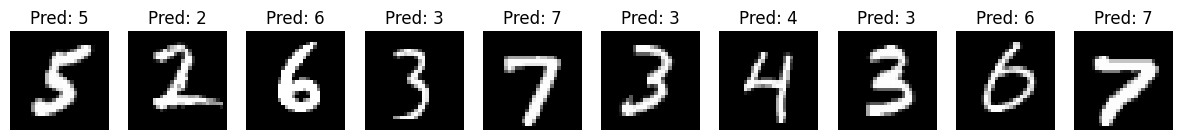

In [147]:
samples, labels = next(iter(test_loader))
samples, labels = samples.to(device), labels.to(device)
predictions = [predict_image(img) for img in samples[:10]]

fig, axes = plt.subplots(1, 10, figsize=(15, 6))
for i, ax in enumerate(axes):
    ax.imshow(samples[i].cpu().squeeze(), cmap="gray")
    ax.set_title(f"Pred: {predictions[i]}")
    ax.axis("off")
plt.show()